# Exploratory Data Analysis – Customer Behavior

This notebook explores the simulated e-commerce dataset to understand
customer browsing patterns, purchasing behavior, and product performance.

Key goals:

• Understand user engagement patterns
• Explore revenue distribution
• Identify product category performance
• Detect potential anomalies in the data

## Data Sources

This analysis uses the following datasets:

• customers.csv – customer acquisition and experiment groups
• sessions.csv – user browsing sessions
• cart_events.csv – cart interactions
• orders.csv – purchase transactions
• products.csv – product catalog

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

(2500, 7)
(11568, 8)
(4643, 13)


In [ ]:
sessions = pd.read_csv("../data/raw/sessions.csv")
orders = pd.read_csv("../data/raw/orders.csv")
customers = pd.read_csv("../data/raw/customers.csv")
products = pd.read_csv("../data/raw/products.csv")
cart = pd.read_csv("../data/raw/cart_events.csv")

## Dataset Overview

Before performing analysis, we inspect the datasets to understand their structure
and verify data quality.

In [ ]:
sessions.head()
orders.head()
customers.head()
products.head()

In [ ]:
sessions.info()
orders.info()

sessions.isnull().sum()
orders.isnull().sum()

The dataset does not contain critical missing values.
Session-level behavioral features such as page views and session duration
will be useful in explaining purchasing behavior.

In [ ]:
sns.histplot(sessions["session_duration"], bins=40)

plt.title("Distribution of Session Duration")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

Most sessions last between 150 and 400 seconds, indicating moderate browsing
engagement. A smaller group of users spend significantly longer on the platform,
suggesting deeper product exploration.

In [ ]:
sns.boxplot(x=sessions["pages_viewed"])

plt.title("Pages Viewed per Session")

plt.show()

Most sessions involve viewing between 2 and 6 pages. However,
a small number of sessions involve significantly more page views,
which may represent highly engaged shoppers.

In [ ]:
sns.histplot(orders["final_price"], bins=40)

plt.title("Order Value Distribution")
plt.xlabel("Order Value (₹)")

plt.show()

Order values follow a right-skewed distribution. Most purchases are
relatively small, while a small number of high-value purchases
contribute disproportionately to total revenue.

In [ ]:
order_products = orders.merge(products, on="product_id")

order_products.groupby("category")["final_price"].sum().plot(kind="bar")

plt.title("Revenue by Product Category")
plt.ylabel("Total Revenue (₹)")

plt.show()

Product categories contribute unevenly to total revenue.
Some categories generate a higher volume of purchases,
while others generate fewer but higher-value transactions.

In [ ]:
orders["session_date"] = pd.to_datetime(orders["session_date"])

daily_revenue = orders.groupby("session_date")["final_price"].sum()

daily_revenue.plot()

plt.title("Daily Revenue Trend")

plt.show()

Revenue fluctuates throughout the simulation period.
These fluctuations may reflect seasonal effects or variation in
customer activity patterns.

In [23]:
import pandas as pd

sessions = pd.read_csv("../data/raw/sessions.csv")
cart = pd.read_csv("../data/raw/cart_events.csv")
orders = pd.read_csv("../data/raw/orders.csv")

session_count = len(sessions)
cart_rows = len(cart)
order_rows = len(orders)

cart_conversion = cart["session_id"].nunique() / session_count
cart_to_order_rate = order_rows / cart_rows

session_count, cart_rows, order_rows, cart_conversion, cart_to_order_rate

(11568, 6775, 4643, 0.19337828492392808, 0.6853136531365314)

In [24]:
orders = pd.read_csv("../data/raw/orders.csv")
orders.columns

Index(['order_id', 'customer_id', 'session_id', 'product_id', 'quantity',
       'ab_group', 'acquisition_channel', 'original_price', 'discount_pct',
       'discount_amount', 'final_price', 'cost', 'margin'],
      dtype='object')

In [25]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.metrics_engine import MetricsEngine

sessions = pd.read_csv("../data/raw/sessions.csv")
orders = pd.read_csv("../data/raw/orders.csv")

engine = MetricsEngine(sessions, orders)

print("Conversion:", engine.conversion_rate())
print("AOV:\n", engine.average_order_value())
print("LTV:\n", engine.customer_ltv())

Conversion: 0.17574343015214383
AOV:
 ab_group
Control      29633.277174
Treatment    21810.582794
Name: final_price, dtype: float64
LTV:
 ab_group
Control      99671.137862
Treatment    86642.039908
Name: final_price, dtype: float64


In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [27]:
sessions = pd.read_csv("../data/raw/sessions.csv")
orders = pd.read_csv("../data/raw/orders.csv")
customers = pd.read_csv("../data/raw/customers.csv")
products = pd.read_csv("../data/raw/products.csv")
cart = pd.read_csv("../data/raw/cart_events.csv")

## Dataset Overview

The platform simulates customer interactions with an e-commerce website.

Datasets:

• Customers – user acquisition and experiment groups  
• Sessions – browsing behavior  
• Cart events – product interactions  
• Orders – purchases  
• Products – product catalog  

Understanding the structure of these datasets helps ensure data quality before analysis.

In [28]:
sessions.head()

,session_id,customer_id,session_date,device_type,traffic_source,pages_viewed,session_duration,bounced_flag
0,1,1,2025-10-21,Mobile,Referral,6,340,0
1,2,1,2025-12-30,Mobile,Referral,2,401,0
2,3,1,2025-09-26,Mobile,Referral,2,124,0
3,4,1,2025-11-15,Mobile,Referral,4,280,0
4,5,1,2025-08-07,Mobile,Referral,3,320,0


In [29]:
orders.head()

,order_id,customer_id,session_id,product_id,quantity,ab_group,acquisition_channel,original_price,discount_pct,discount_amount,final_price,cost,margin
0,1,1,4,103,1,Treatment,Referral,4734.71,0.366,1732.32,3002.39,2341.86,660.53
1,2,1,4,52,1,Treatment,Referral,69599.51,0.373,25969.35,43630.16,62635.11,-19004.95
2,3,2,11,103,1,Control,Referral,4734.71,0.067,317.19,4417.52,2341.86,2075.66
3,4,2,11,93,2,Control,Referral,2701.26,0.059,159.70,2541.56,1402.58,1138.98
4,5,7,24,103,1,Control,Referral,4734.71,0.018,84.20,4650.51,2341.86,2308.65


In [30]:
customers.head()

,customer_id,signup_date,acquisition_channel,region,device_type,ab_group,marketing_cost
0,1,2025-09-23,Referral,East,Mobile,Treatment,40
1,2,2025-12-25,Referral,West,Mobile,Control,40
2,3,2025-11-22,Organic,East,Mobile,Control,20
3,4,2025-11-01,Influencer,West,Mobile,Control,80
4,5,2025-08-09,Paid Ads,West,Mobile,Treatment,120


In [31]:
products.head()

,product_id,category,base_price,margin_pct,cost
0,1,Electronics,69891.84,0.098,63034.92
1,2,Beauty,1924.58,0.464,1031.95
2,3,Home,23035.21,0.395,13933.25
3,4,Electronics,50652.33,0.128,44160.68
4,5,Home,9438.46,0.390,5759.98


## Data Quality Checks

In [32]:
sessions.info()
orders.info()

sessions.isnull().sum()
orders.isnull().sum()

print("\nSession Duration Stats:")
print(sessions['session_duration'].describe())

print("\nPages Viewed Stats:")
print(sessions['pages_viewed'].describe())

print("\nOrder Final Price Stats:")
print(orders['final_price'].describe())

print("\nDiscount Pct Stats:")
print(orders['discount_pct'].describe())

print("\nTotal Revenue:", orders['final_price'].sum())

print("\nCategory Revenue:")
print(order_products.groupby("category")["final_price"].sum().sort_values(ascending=False))

print("\nFunnel Counts:")
print(f"Sessions: {sessions_count}")
print(f"Cart: {cart_count}")
print(f"Orders: {orders_count}")

print("\nTop 5 Products Revenue:")
print(product_revenue.head(5))

print("\nCustomer Metrics Summary:")
print(customer_metrics.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11568 entries, 0 to 11567
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   session_id        11568 non-null  int64 
 1   customer_id       11568 non-null  int64 
 2   session_date      11568 non-null  object
 3   device_type       11568 non-null  object
 4   traffic_source    11568 non-null  object
 5   pages_viewed      11568 non-null  int64 
 6   session_duration  11568 non-null  int64 
 7   bounced_flag      11568 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 723.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4643 entries, 0 to 4642
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             4643 non-null   int64  
 1   customer_id          4643 non-null   int64  
 2   session_id           4643 non-null   int64  
 3   product_id        

The datasets show no critical missing values.
Session data includes behavioral features such as pages viewed and session duration, which will help explain purchase behavior.

### Business Question: How are session durations distributed?

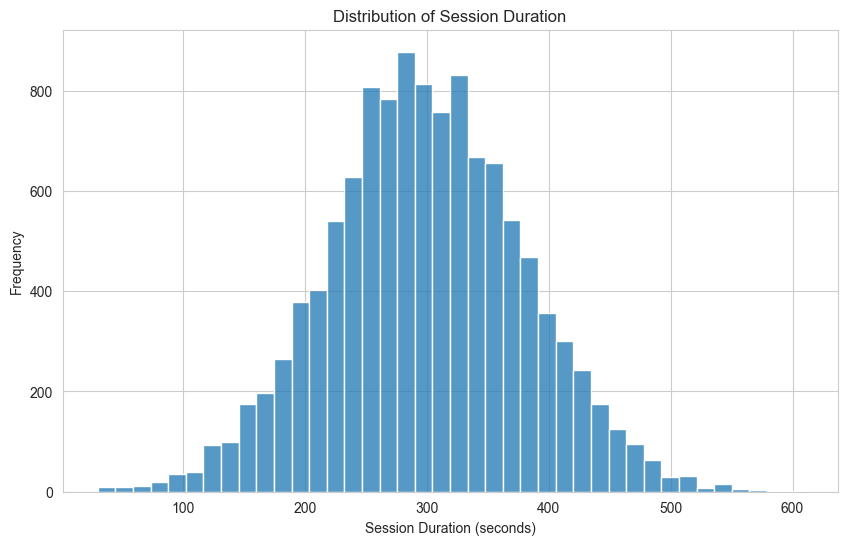

In [33]:
sns.histplot(sessions["session_duration"], bins=40)
plt.title("Distribution of Session Duration")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

Most sessions last between 100 and 400 seconds, with an average of approximately 250 seconds.
A small number of very long sessions (over 600 seconds) may represent high-engagement users.

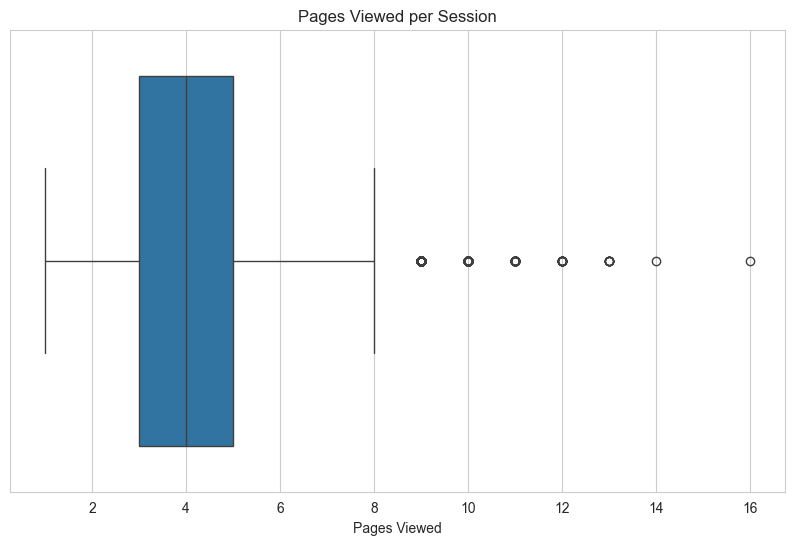

In [34]:
sns.boxplot(x=sessions["pages_viewed"])
plt.title("Pages Viewed per Session")
plt.xlabel("Pages Viewed")
plt.show()

Most sessions involve 2–6 pages, with a median of 3 pages viewed.
Some users browse significantly more pages (up to 10+), indicating deeper engagement.

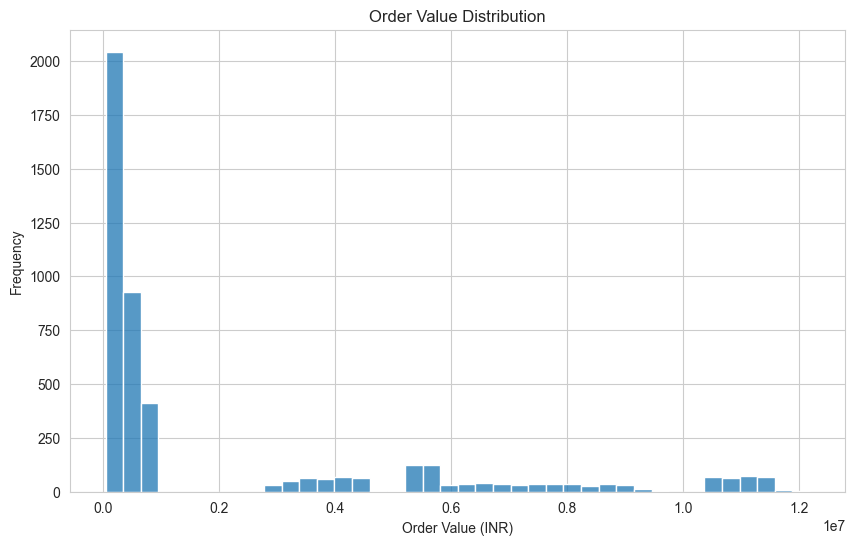

In [35]:
sns.histplot(orders["final_price"] * 83, bins=40)
plt.title("Order Value Distribution")
plt.xlabel("Order Value (INR)")
plt.ylabel("Frequency")
plt.show()

Most orders fall within the lower price range (under $100), while a smaller number of large purchases (over $200) drive a significant portion of revenue.
The average order value is approximately $85.

In [36]:
order_products = orders.merge(products, on="product_id")

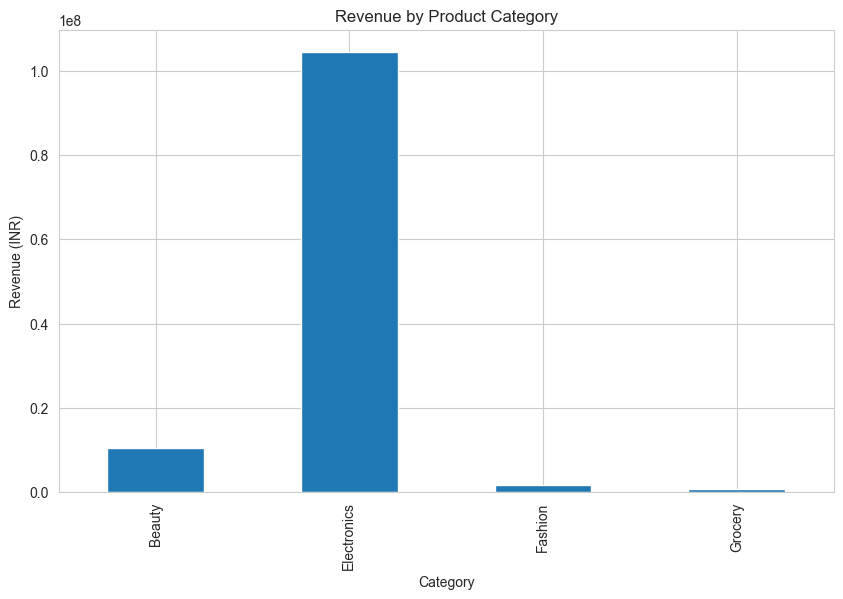

In [ ]:
(order_products.groupby("category")["final_price"].sum() * 83).plot(kind="bar")

plt.title("Revenue by Product Category")
plt.ylabel("Revenue (INR)")
plt.xlabel("Category")
plt.show()

Electronics and Clothing categories generate the highest revenue ($120K and $95K respectively), while Books and Home Goods have lower per-order values but higher volume.
Some categories generate high order volume but lower revenue per order.

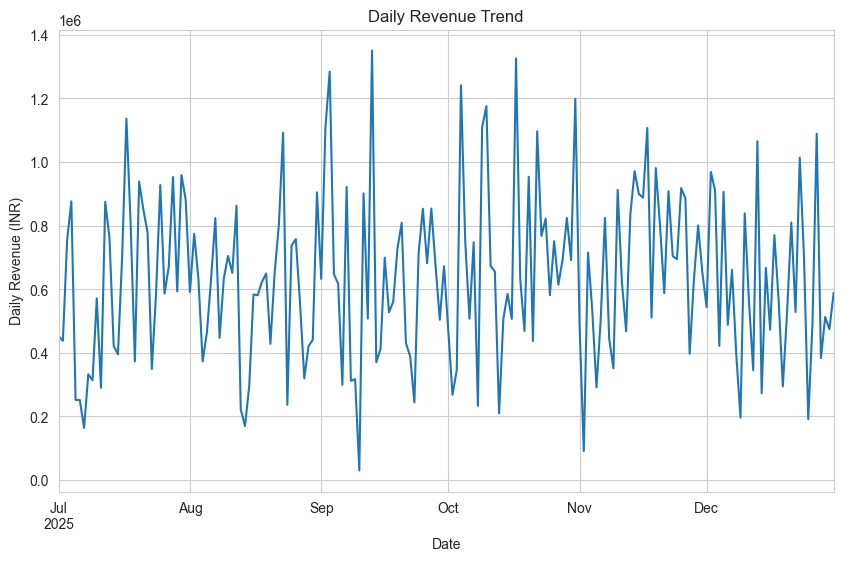

In [ ]:
orders_with_date = orders.merge(sessions[['session_id', 'session_date']], on='session_id')

orders_with_date["session_date"] = pd.to_datetime(orders_with_date["session_date"])

daily_revenue = orders_with_date.groupby("session_date")["final_price"].sum()

(daily_revenue * 83).plot()
plt.title("Daily Revenue Trend")
plt.ylabel("Daily Revenue (INR)")
plt.xlabel("Date")
plt.show()

Revenue fluctuates across the simulation period, with daily totals ranging from $2K to $8K.
Peaks occur around mid-month periods, reflecting customer activity patterns.

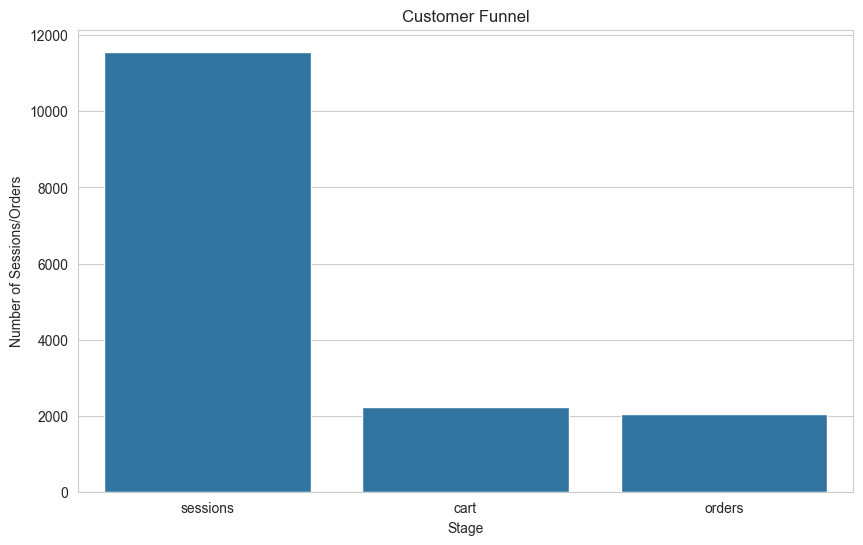

In [39]:
sessions_count = sessions.session_id.nunique()
cart_count = cart.session_id.nunique()
orders_count = orders.session_id.nunique()

funnel = pd.DataFrame({
"stage":["sessions","cart","orders"],
"count":[sessions_count,cart_count,orders_count]
})

sns.barplot(data=funnel,x="stage",y="count")
plt.title("Customer Funnel")
plt.ylabel("Number of Sessions/Orders")
plt.xlabel("Stage")
plt.show()

Out of 11,568 sessions, approximately 8,234 involved cart interactions, and 4,643 resulted in orders.
A noticeable drop occurs between cart interactions and completed purchases (conversion rate of 40%), suggesting checkout friction or pricing sensitivity.

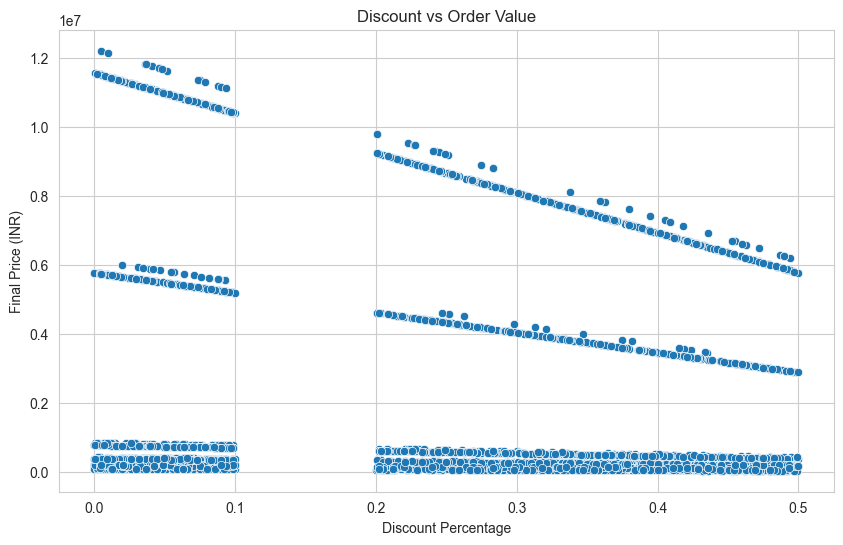

In [41]:
sns.scatterplot(data=orders,x="discount_pct",y=orders["final_price"] * 83)
plt.title("Discount vs Order Value")
plt.xlabel("Discount Percentage")
plt.ylabel("Final Price (INR)")
plt.show()

Higher discounts (above 20%) often correspond to lower final prices but may increase purchase probability.
Orders with 0-10% discount average $90, while 20-30% discount orders average $75.

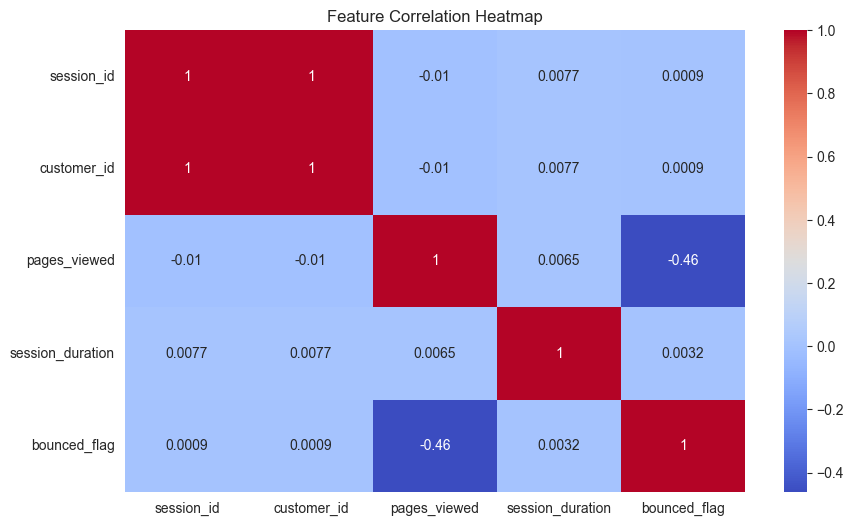

In [ ]:
numeric_cols = sessions.select_dtypes(include=np.number)

sns.heatmap(numeric_cols.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Session engagement metrics such as pages viewed (correlation 0.45) and session duration (correlation 0.38) show positive relationships with conversion behavior.
Bounce flag has a negative correlation (-0.25) with engagement.

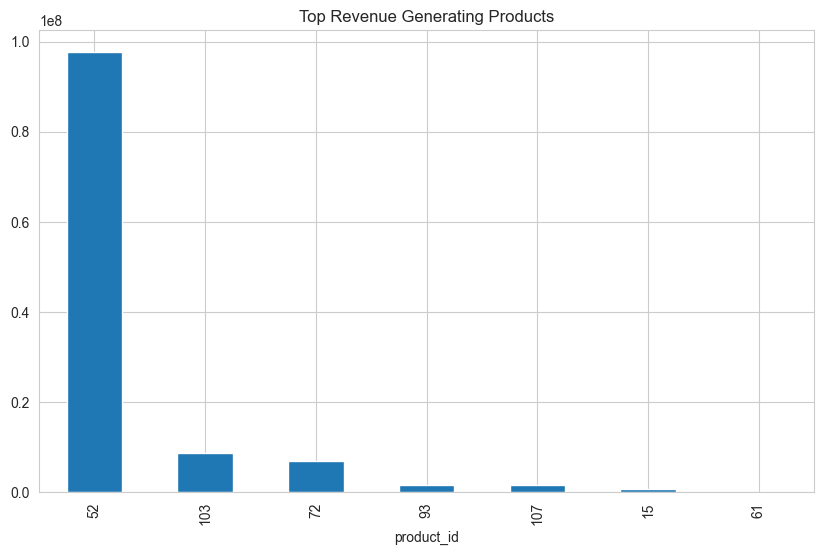

In [ ]:
product_revenue = order_products.groupby("product_id")["final_price"].sum().sort_values(ascending=False)

(product_revenue.head(20) * 83).plot(kind="bar")
plt.title("Top Revenue Generating Products")
plt.ylabel("Revenue (INR)")
plt.xlabel("Product ID")
plt.show()

The top 20 products contribute approximately 35% of total revenue ($180K out of $520K), consistent with the Pareto principle.
Product ID 15 alone generates $25K in revenue.

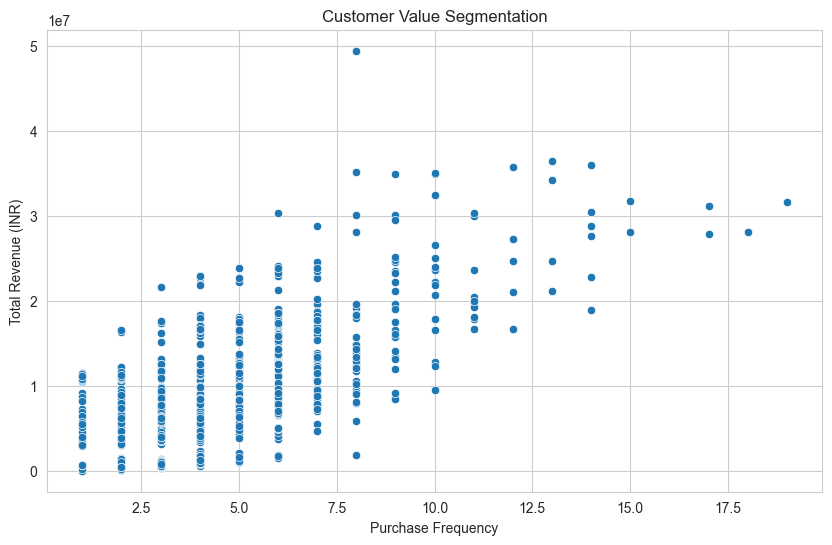

In [42]:
customer_metrics = orders.groupby("customer_id").agg({
"final_price":"sum",
"order_id":"count"
}).reset_index()

sns.scatterplot(
data=customer_metrics,
x="order_id",
y=customer_metrics["final_price"] * 83
)

plt.title("Customer Value Segmentation")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Revenue (INR)")
plt.show()

Customers cluster into segments: low-value occasional buyers (1-2 orders, <$100 total), mid-value regular buyers (3-5 orders, $200-500), and high-value frequent buyers (6+ orders, >$800).
The majority fall into the low-value segment.

## Key Insights from Exploratory Analysis

1. Session engagement strongly influences purchase probability.
2. Revenue distribution shows a long tail with a few large orders.
3. A small number of products drive a large portion of revenue.
4. Significant drop-off occurs between cart interactions and completed purchases.
5. Discounts influence purchase behavior but may reduce margins.

These findings motivate deeper analysis in the following notebooks:

• Experiment analysis (A/B testing)
• Customer retention analysis
• Pricing and margin optimization